In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from PIL import Image
from skimage import io, color, filters, measure
from skimage.measure import perimeter, regionprops
from sklearn.cluster import KMeans
from tqdm import tqdm
import warnings
from skimage.color import rgb2lab
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.cm as cm
from sklearn.manifold import TSNE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("HAM10000_Dataset/HAM10000_metadata.csv")
df = df.drop(columns=["dx_type", "lesion_id"])
df

,image_id,dx,age,sex,localization
0,ISIC_0027419,nomel,80.0,male,scalp
1,ISIC_0025030,nomel,80.0,male,scalp
2,ISIC_0026769,nomel,80.0,male,scalp
3,ISIC_0025661,nomel,80.0,male,scalp
4,ISIC_0031633,nomel,75.0,male,ear
...,...,...,...,...,...
10010,ISIC_0033084,nomel,40.0,male,abdomen
10011,ISIC_0033550,nomel,40.0,male,abdomen
10012,ISIC_0033536,nomel,40.0,male,abdomen
10013,ISIC_0032854,nomel,80.0,male,face


In [3]:
mel_count = (df["dx"] == "mel").sum()
nomel_count = (df["dx"] == "nomel").sum()
mel_prct = (mel_count / (mel_count + nomel_count)) * 100 

print("MEL :", mel_count)
print("NOMEL :", nomel_count)
print("%MEL :", mel_prct)

MEL : 1113
NOMEL : 8902
%MEL : 11.11333000499251


In [4]:
image_dir = "images"
mask_dir = "masks"

In [13]:
def vertical_asymmetry(mask):
    cols = mask.shape[1] // 2
    left = mask[:, :cols]
    right = np.fliplr(mask[:, -cols:])
    min_cols = min(left.shape[1], right.shape[1])
    diff = np.bitwise_xor(left[:, :min_cols], right[:, :min_cols])
    vert_sym = (diff.sum() / mask.sum())*100
    return vert_sym

def horizontal_asymmetry(mask):
    # Masque coupé en deux horizontalement
    rows = mask.shape[0] // 2
    top = mask[:rows, :]
    bottom = np.flipud(mask[-rows:, :])
    min_rows = min(top.shape[0], bottom.shape[0])
    diff = np.bitwise_xor(top[:min_rows, :], bottom[:min_rows, :])
    horizon_sym = (diff.sum() / mask.sum())*100
    return horizon_sym

In [6]:
def extract_dominant_colors(img, mask, n_colors=3):
    pixels_inside = img[mask]  # pixels des zones masquées
    kmeans = KMeans(n_clusters=n_colors, random_state=0).fit(pixels_inside * 255)
    dominant_colors = kmeans.cluster_centers_  # centres en RGB 0-255
    labels, counts = np.unique(kmeans.labels_, return_counts=True)
    proportions = counts / counts.sum()  # proportions des clusters

    return dominant_colors, proportions

In [7]:
def shape_features_from_mask(mask):
    area = mask.sum()

    perim = perimeter(mask)

    props = regionprops(mask.astype(int))
    if len(props) > 0:
        r = props[0]
        eccentricity = r.eccentricity
    else:
        eccentricity = np.nan

    circularity = 4 * np.pi * area / (perim**2 + 1e-8)

    return area, perim, circularity, eccentricity


In [8]:
data = []
images_list = []
masks_list = []

for img_id in tqdm(df["image_id"], desc="Extraction features"):
    img_path = f"HAM10000_Dataset/HAM10000/{img_id}.jpg"
    mask_path = f"HAM10000_Dataset/HAM10000_segmentations_lesion_tschandl/{img_id}_segmentation.png"
    img = np.array(Image.open(img_path).convert('RGB')) / 255.0
    mask = np.array(Image.open(mask_path).convert('L')) > 0  # booléen
    #print("Image :", img_id)

    #En niveau de gris
    gray = color.rgb2gray(img)

    #Couleur dominante
    dominant_colors, proportions = extract_dominant_colors(img, mask, n_colors=3)
    
    #Asymétrie
    vert_asym = vertical_asymmetry(mask)
    horizon_asym = horizontal_asymmetry(mask)  

    #shape_features 
    area, perim, circularity, eccentricity = shape_features_from_mask(mask)
    
    '''#Affichage
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{img_id} - Image")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.title(f"{img_id} - Masque")

    plt.show()
    #display(img)'''

    # Ajouter les features dans la liste
    row = {"image_id": img_id}
    for i in range(3):
        row[f'color_{i+1}_R'] = dominant_colors[i][0]
        row[f'color_{i+1}_G'] = dominant_colors[i][1]
        row[f'color_{i+1}_B'] = dominant_colors[i][2]
        row[f'color_{i+1}_proportion'] = proportions[i]
    row['asym_vert_%'] = vert_asym
    row['asym_horiz_%'] = horizon_asym
    row['Perimeter'] = perim
    row['Area'] = area
    row['circularity'] = circularity
    row['eccentricity'] = eccentricity

    data.append(row)



# Conversion en DataFrame
features_df = pd.DataFrame(data)
final_df = pd.merge(df, features_df, on='image_id', how='inner')
final_df

Extraction features: 100%|██████████| 10015/10015 [06:18<00:00, 26.46it/s]


,image_id,dx,age,sex,localization,color_1_R,color_1_G,color_1_B,color_1_proportion,color_2_R,...,color_3_R,color_3_G,color_3_B,color_3_proportion,asym_vert_%,asym_horiz_%,Perimeter,Area,circularity,eccentricity
0,ISIC_0027419,nomel,80.0,male,scalp,219.179990,177.235439,198.679157,0.457572,184.425591,...,207.771385,150.836506,157.093755,0.390716,19.105153,17.450459,1251.785930,85333,0.684332,0.686623
1,ISIC_0025030,nomel,80.0,male,scalp,226.107693,187.273683,205.974215,0.442245,189.566767,...,214.179005,158.707311,160.624952,0.404999,35.036812,16.117057,754.488419,32326,0.713603,0.534008
2,ISIC_0026769,nomel,80.0,male,scalp,198.104553,122.933030,132.345778,0.168120,224.884205,...,217.491455,150.013374,164.787046,0.429084,16.548578,15.708324,1114.560533,72121,0.729565,0.646662
3,ISIC_0025661,nomel,80.0,male,scalp,227.012822,170.157376,192.372925,0.345771,217.576529,...,196.976197,117.661687,125.351988,0.185448,19.936487,28.734881,598.215295,21413,0.751921,0.676903
4,ISIC_0031633,nomel,75.0,male,ear,215.138856,162.599185,184.575606,0.301135,145.233630,...,184.497142,129.514243,139.646944,0.433511,24.592457,17.613228,1274.011327,102934,0.796934,0.418797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,ISIC_0033084,nomel,40.0,male,abdomen,148.506775,101.631723,97.752969,0.213116,214.066087,...,184.334036,138.683070,136.519719,0.290280,15.381048,18.506901,1562.822510,146648,0.754513,0.704614
10011,ISIC_0033550,nomel,40.0,male,abdomen,205.608162,160.438709,161.972693,0.495766,175.788089,...,141.078120,92.865797,88.159177,0.215991,14.037954,11.100383,924.648845,53854,0.791542,0.693115
10012,ISIC_0033536,nomel,40.0,male,abdomen,232.295149,191.089008,191.237413,0.494415,163.062171,...,200.012468,152.132820,146.205180,0.289340,13.481511,13.215853,1129.986940,79049,0.777964,0.712581
10013,ISIC_0032854,nomel,80.0,male,face,198.650101,174.036274,183.928216,0.428142,181.533601,...,192.057606,153.046401,160.976969,0.365636,35.563498,19.522941,1657.449927,137090,0.627097,0.488606


In [9]:
#final_df.to_csv("HAM10000_features_couleurs_V2.csv", index=False)

In [5]:
df = pd.read_csv("HAM10000_features_couleurs.csv")

In [6]:
feature_cols = [
    "Area", "Perimeter", "circularity", "eccentricity",
    "color_1_R","color_1_G","color_1_B","color_1_proportion",
    "color_2_R","color_2_G","color_2_B","color_2_proportion",
    "color_3_R","color_3_G","color_3_B","color_3_proportion",
    "asym_vert_%","asym_horiz_%"
]

Variance expliquée (PCA1, PCA2): [0.21093442 0.1546653 ]


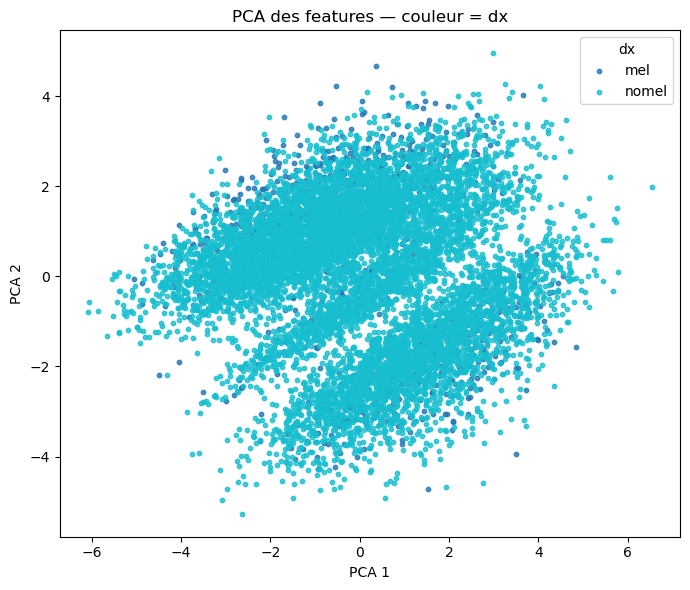

In [7]:
X = df[feature_cols].values
labels = df["dx"].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)
print("Variance expliquée (PCA1, PCA2):", pca.explained_variance_ratio_)

# Graphique PCA
plt.figure(figsize=(7, 6))

cats = pd.Categorical(labels).categories
cmap = cm.get_cmap("tab10", len(cats))

for i, dx in enumerate(cats):
    mask_dx = (labels == dx)
    plt.scatter(
        X_pca[mask_dx, 0],
        X_pca[mask_dx, 1],
        s=10,
        alpha=0.8,
        color=cmap(i),
        label=dx
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA des features — couleur = dx")
plt.legend(title="dx", loc="best")
plt.tight_layout()
plt.show()

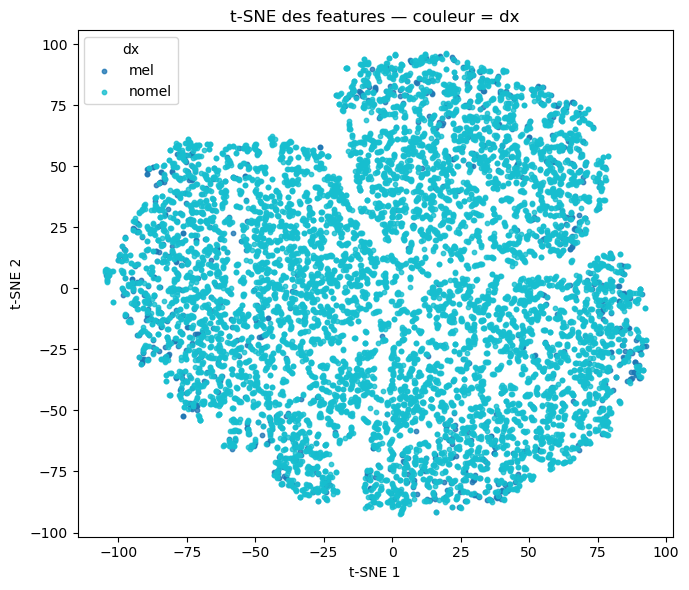

In [6]:
# 3) t-SNE 2D
tsne = TSNE(
    n_components=2,
    perplexity=10,      
    learning_rate="auto",
    n_iter=1000,
    init="pca",
    random_state=0
)
X_tsne = tsne.fit_transform(X_scaled)

# 4) Plot t-SNE coloré par dx
plt.figure(figsize=(7, 6))

cats = pd.Categorical(labels).categories
cmap = cm.get_cmap("tab10", len(cats))

for i, dx in enumerate(cats):
    mask_dx = (labels == dx)
    plt.scatter(
        X_tsne[mask_dx, 0],
        X_tsne[mask_dx, 1],
        s=10,
        alpha=0.8,
        color=cmap(i),
        label=dx
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE des features — couleur = dx")
plt.legend(title="dx", loc="best")
plt.tight_layout()
plt.show()

#CNN classique#

In [8]:
input_shape = (128, 128, 3)  # adapte à ton resize
num_classes = 2  # mel / non-mel

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
df["label"] = (df["dx"] == "mel").astype(int)  # 1 = mel, 0 = non-mel
nb_ones = (df["label"] == 1).sum()
nb_ones

1113

In [10]:
IMG_SIZE = (128, 128)

def load_image(img_id):
    img_path = f"HAM10000_Dataset/HAM10000/{img_id}.jpg"
    img = Image.open(img_path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img = np.array(img, dtype=np.float32) / 255.0
    return img


In [29]:
X = np.stack([load_image(img_id) for img_id in df["image_id"]])
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [18]:
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs= 50,
    batch_size=32,
    callbacks=[callback]
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy = {test_acc:.3f}")


Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 55s 241ms/step - accuracy: 0.8760 - loss: 0.3646 - val_accuracy: 0.8888 - val_loss: 0.3052
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 54s 248ms/step - accuracy: 0.8919 - loss: 0.3082 - val_accuracy: 0.8888 - val_loss: 0.2773
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 53s 242ms/step - accuracy: 0.8886 - loss: 0.2838 - val_accuracy: 0.8888 - val_loss: 0.2627
Epoch 4/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 53s 241ms/step - accuracy: 0.8954 - loss: 0.2686 - val_accuracy: 0.8842 - val_loss: 0.2640
Epoch 5/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 53s 240ms/step - accuracy: 0.8963 - loss: 0.2519 - val_accuracy: 0.8875 - val_loss: 0.2607
Epoch 6/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 53s 240ms/step - accuracy: 0.8871 - loss: 0.2697 - val_accuracy: 0.8895 - val_loss: 0.2593
Epoch 7/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 53s 242ms/step - accuracy: 0.8854 - loss: 0.2683 - val_accuracy: 0.8888 - val_loss: 0.2539
Epoch 8/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 53s 242ms/step - accuracy: 0.8938 - loss: 0

In [13]:
print(len(X_train), len(X_val), len(X_test))
np.unique(y_train, return_counts=True)
np.unique(y_test, return_counts=True)


7010 1502 1503


(array([0, 1]), array([1336,  167], dtype=int64))

In [14]:
print("Train:", np.unique(y_train, return_counts=True))
print("Val  :", np.unique(y_val, return_counts=True))
print("Test :", np.unique(y_test, return_counts=True))


Train: (array([0, 1]), array([6231,  779], dtype=int64))
Val  : (array([0, 1]), array([1335,  167], dtype=int64))
Test : (array([0, 1]), array([1336,  167], dtype=int64))


In [15]:
#model.save("cnn_melanome.keras")

#CNN Transfer#

In [32]:
IMG_SIZE = (128, 128)

def load_image_for_vgg(img_id):
    path = f"HAM10000_Dataset/HAM10000/{img_id}.jpg"
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img = np.array(img, dtype=np.float32)
    img = preprocess_input(img)   # prétraitement spécifique VGG16
    return img

X = np.stack([
    load_image_for_vgg(img_id)
    for img_id in tqdm(df["image_id"], desc="Chargement images VGG")
])
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


Chargement images VGG: 100%|██████████| 10015/10015 [01:09<00:00, 144.16it/s]


In [13]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
)

# Geler les couches du backbone au début
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model_tl = Model(inputs=base_model.input, outputs=output)

model_tl.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_tl.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model_tl.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[callback]
)


Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 133s 599ms/step - accuracy: 0.7771 - loss: 1.1889 - val_accuracy: 0.8895 - val_loss: 0.4749
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 124s 562ms/step - accuracy: 0.8451 - loss: 0.6715 - val_accuracy: 0.8948 - val_loss: 0.4019
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 123s 558ms/step - accuracy: 0.8645 - loss: 0.5033 - val_accuracy: 0.8955 - val_loss: 0.3309
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 120s 547ms/step - accuracy: 0.8601 - loss: 0.4331 - val_accuracy: 0.8995 - val_loss: 0.2938
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 123s 558ms/step - accuracy: 0.8679 - loss: 0.3798 - val_accuracy: 0.8975 - val_loss: 0.2819
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 121s 549ms/step - accuracy: 0.8759 - loss: 0.3315 - val_accuracy: 0.9021 - val_loss: 0.2892
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 121s 552ms/step - accuracy: 0.8940 - loss: 0.2877 - val_accuracy: 0.9035 - val_loss: 0.2830
Epoch 8/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 121s 552ms/step - accuracy: 0.8928 -

In [16]:
test_loss, test_acc = model_tl.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy (VGG16 TL): {test_acc:.3f}")

#model_tl.save("cnn_vgg16_transfer_melanome.keras")


NameError: name 'model_tl' is not defined

In [33]:
# Charger le modèle déjà sauvegardé
model = tf.keras.models.load_model("cnn_vgg16_transfer_melanome.keras")

# Prédire sur ton X_test
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int).ravel()


47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 486ms/step


In [34]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix about the VGG16 CNN:")
print(cm)
print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

# Rapport de classification (optionnel mais utile)
print("\nClassification report :")
print(classification_report(y_test, y_pred))

Confusion Matrix about the VGG16 CNN:
[[1307   29]
 [ 119   48]]
TN: 1307, FP: 29, FN: 119, TP: 48

Classification report :
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1336
           1       0.62      0.29      0.39       167

    accuracy                           0.90      1503
   macro avg       0.77      0.63      0.67      1503
weighted avg       0.88      0.90      0.88      1503



In [ ]:
#faire matrice de confusion pour les deux

In [30]:
# Charger le modèle déjà sauvegardé
model = tf.keras.models.load_model("cnn_melanome.keras")

# Prédire sur ton X_test
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int).ravel()


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step


In [31]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix about the CNN from scratch :")
print(cm)
print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

# Rapport de classification (optionnel mais utile)
print("\nClassification report :")
print(classification_report(y_test, y_pred))

Confusion Matrix about the CNN from scratch :
[[1311   25]
 [ 129   38]]
TN: 1311, FP: 25, FN: 129, TP: 38

Classification report :
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1336
           1       0.60      0.23      0.33       167

    accuracy                           0.90      1503
   macro avg       0.76      0.60      0.64      1503
weighted avg       0.88      0.90      0.88      1503

